# file uploading

In [ ]:
!unzip /content/bajra_sorted.zip

Archive:  /content/bajra_sorted.zip
   creating: bajra_sorted/Downy/
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_105740_jpg.rf.9fe78f677171f746d8df7d5a03cecd7c.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_105745_jpg.rf.e11ca55c84e547e7541e2bebac936a43.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_105801_jpg.rf.4bd05e2354810b6e97fc4812d8102001.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_105815_jpg.rf.ff7c925c40e30036d7bc0eae58dc67a5.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_105816_jpg.rf.e511139f961480e111d61f6b9b047ee5.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_105823_jpg.rf.6c11fab5bacefebfe5d7e25e0a0dc321.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_105930_jpg.rf.b5d5a4ccedc29df42913d9013870ba3d.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG_20210827_110004_jpg.rf.c830627442e1feecadb5aeca690203d4.jpg  
  inflating: bajra_sorted/Downy/Copy-of-IMG20210827103042_jpg.rf.2ff4400081f021d3c8

In [ ]:
!unzip /content/ragi.zip

Archive:  /content/ragi.zip
   creating: ragi/downy/
  inflating: ragi/downy/downymildew (1).jpeg  
  inflating: ragi/downy/downymildew (10).jpg  
  inflating: ragi/downy/downymildew (100).jpg  
  inflating: ragi/downy/downymildew (101).jpg  
  inflating: ragi/downy/downymildew (102).jpg  
  inflating: ragi/downy/downymildew (103).jpg  
  inflating: ragi/downy/downymildew (104).jpg  
  inflating: ragi/downy/downymildew (105).jpg  
  inflating: ragi/downy/downymildew (106).jpg  
  inflating: ragi/downy/downymildew (107).jpg  
  inflating: ragi/downy/downymildew (108).jpg  
  inflating: ragi/downy/downymildew (109).jpg  
  inflating: ragi/downy/downymildew (11).jpeg  
  inflating: ragi/downy/downymildew (110).jpg  
  inflating: ragi/downy/downymildew (111).jpg  
  inflating: ragi/downy/downymildew (112).jpg  
  inflating: ragi/downy/downymildew (113).jpg  
  inflating: ragi/downy/downymildew (114).jpg  
  inflating: ragi/downy/downymildew (115).jpg  
  inflating: ragi/downy/downymildew (

# checking files

🔹 Bajra Images: 339
🔹 Ragi Images: 1514

📊 Analysis for Bajra:
 - Avg Height: 640.00
 - Avg Width: 640.00
 - Avg RGB Mean: [120 140  80]
 - Avg RGB Std: [46 45 44]


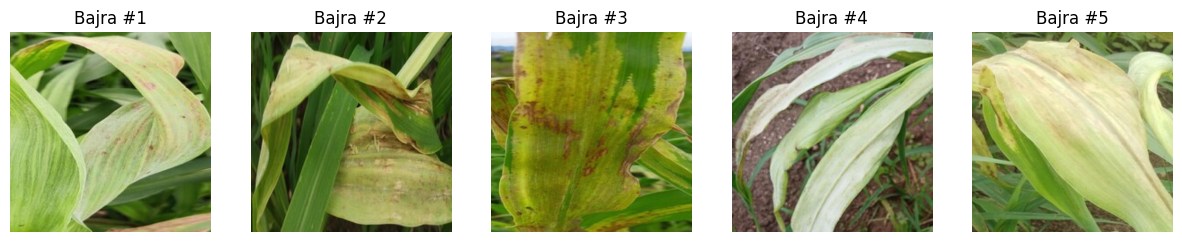


📊 Analysis for Ragi:
 - Avg Height: 309.47
 - Avg Width: 317.12
 - Avg RGB Mean: [109 123  76]
 - Avg RGB Std: [46 46 45]


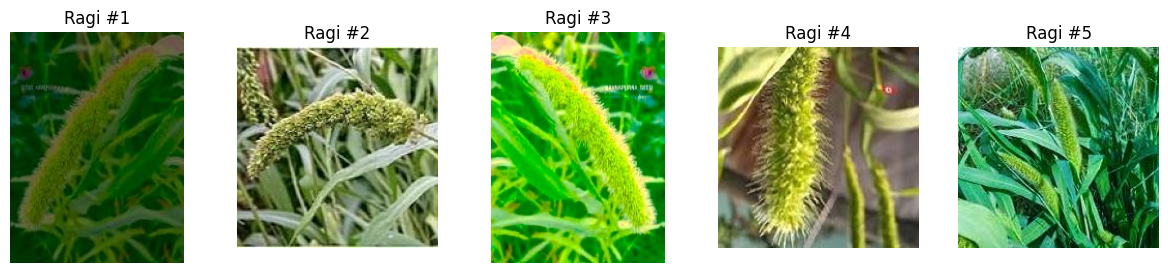

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Paths to your folders
bajra_path = "/content/bajra_sorted"
ragi_path = "/content/ragi"

# Function to recursively get image paths
def get_image_paths_recursive(folder, extensions={'.jpg', '.jpeg', '.png'}):
    paths = []
    for root, dirs, files in os.walk(folder):
        for file in files:
            if os.path.splitext(file)[1].lower() in extensions:
                paths.append(os.path.join(root, file))
    return paths

# Get all image paths
bajra_images = get_image_paths_recursive(bajra_path)
ragi_images = get_image_paths_recursive(ragi_path)

print(f"🔹 Bajra Images: {len(bajra_images)}")
print(f"🔹 Ragi Images: {len(ragi_images)}")

# Analysis function
def analyze_images(image_list, label):
    heights, widths = [], []
    color_means, color_stds = [], []

    for img_path in image_list:
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)
        mean = img_rgb.mean(axis=(0, 1))
        std = img_rgb.std(axis=(0, 1))
        color_means.append(mean)
        color_stds.append(std)

    print(f"\n📊 Analysis for {label}:")
    if heights:
        print(f" - Avg Height: {np.mean(heights):.2f}")
        print(f" - Avg Width: {np.mean(widths):.2f}")
        print(f" - Avg RGB Mean: {np.mean(color_means, axis=0).astype(int)}")
        print(f" - Avg RGB Std: {np.mean(color_stds, axis=0).astype(int)}")
    else:
        print(" - No valid images found for stats.")

    # Plot sample images
    sample_imgs = image_list[:5]
    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(sample_imgs):
        img = Image.open(img_path)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{label} #{i+1}")
    plt.show()

# Run analysis
analyze_images(bajra_images, "Bajra")
analyze_images(ragi_images, "Ragi")


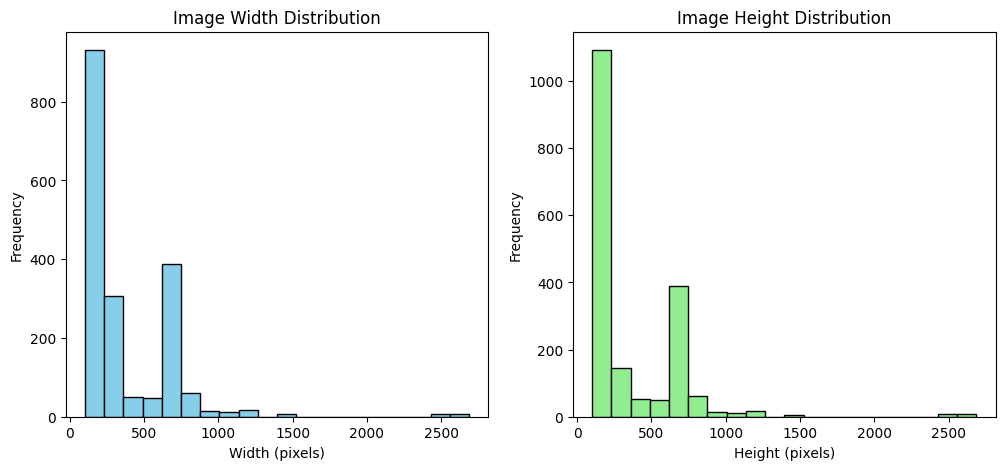

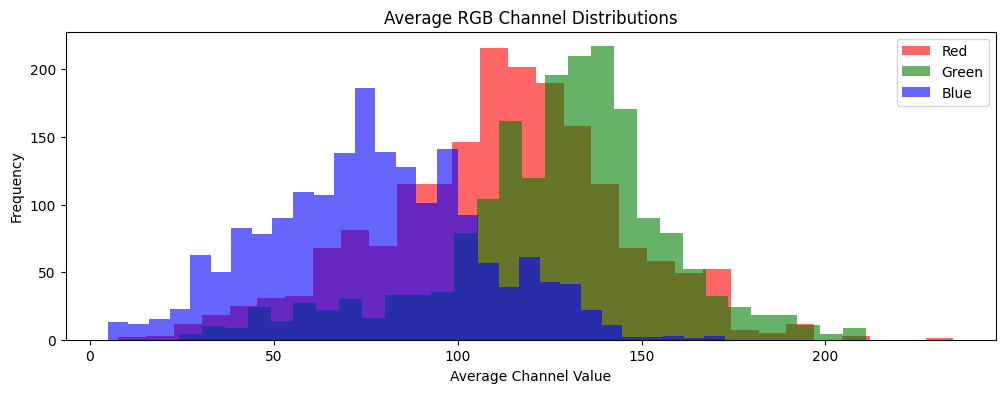

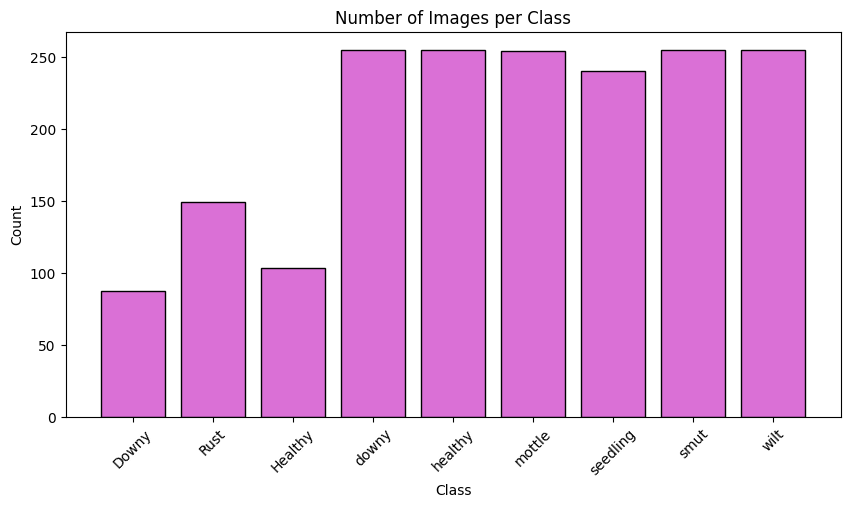

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

def get_images_and_labels(root_dir, extensions={'.jpg', '.jpeg', '.png'}):
    image_paths = []
    labels = []
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if os.path.splitext(file)[1].lower() in extensions:
                image_paths.append(os.path.join(root, file))
                labels.append(os.path.basename(root))  # folder name = label
    return image_paths, labels
bajra_images, bajra_labels = get_images_and_labels("/content/bajra_sorted")
ragi_images, ragi_labels = get_images_and_labels("/content/ragi")
all_images = bajra_images + ragi_images
all_labels = bajra_labels + ragi_labels

widths, heights = [], []
rgb_means = []

for img_path in all_images:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    widths.append(w)
    heights.append(h)
    rgb_means.append(img_rgb.mean(axis=(0, 1)))  # [R,G,B]

rgb_means = np.array(rgb_means)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='skyblue', edgecolor='black')
plt.title('Image Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='lightgreen', edgecolor='black')
plt.title('Image Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12,4))
plt.hist(rgb_means[:,0], bins=30, color='r', alpha=0.6, label='Red')
plt.hist(rgb_means[:,1], bins=30, color='g', alpha=0.6, label='Green')
plt.hist(rgb_means[:,2], bins=30, color='b', alpha=0.6, label='Blue')
plt.title('Average RGB Channel Distributions')
plt.xlabel('Average Channel Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

all_class_counts = Counter(bajra_labels) + Counter(ragi_labels)
classes, counts = zip(*all_class_counts.items())

plt.figure(figsize=(10,5))
plt.bar(classes, counts, color='orchid', edgecolor='black')
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


# work on ragi

Found 1514 files belonging to 6 classes.
Using 1212 files for training.
Found 1514 files belonging to 6 classes.
Using 302 files for validation.
Classes: ['downy', 'healthy', 'mottle', 'seedling', 'smut', 'wilt']
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.2210 - loss: 1.8835 - val_accuracy: 0.4901 - val_loss: 1.4125
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.4589 - loss: 1.3262 - val_accuracy: 0.6126 - val_loss: 1.0219
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.5865 - loss: 1.0120 - val_accuracy: 0.6921 - val_loss: 0.8486
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6672 - loss: 0.8634 - val_accuracy: 0.7682 - val_loss: 0.6639
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7961 - loss: 0.5977 - val_accuracy: 0.7583 - val_loss: 0.6397
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8198 - loss: 0.4843 - val_accuracy: 0.8079 - val_loss: 0.4552
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8385 - loss: 0.4239 - val_accuracy: 0.8808 - val_loss: 0.3723
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8813 - loss: 0.3219 - val_accuracy: 0.8344 - val_loss: 0.4865
E

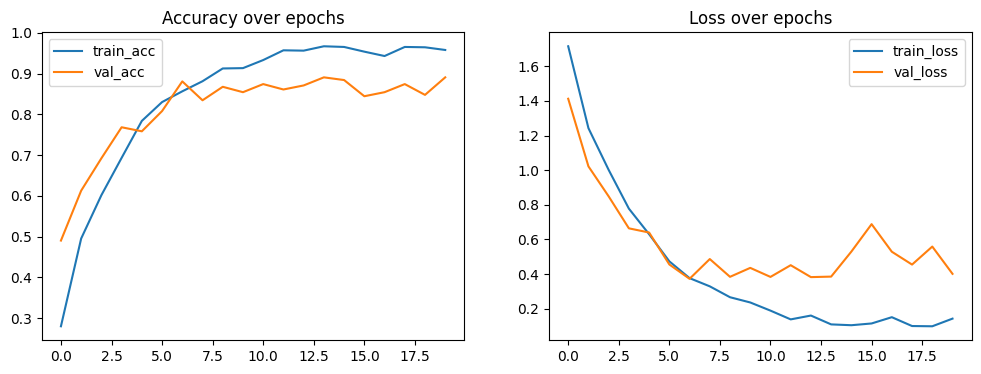

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ✅ Load dataset
data_dir = '/content/ragi'

# Create training & validation datasets
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

# ✅ Improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ✅ Build CNN model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ✅ Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# ✅ Plot training results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.legend()

plt.show()


Selected image: /content/ragi/mottle/mottle_streak (82).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
🔍 Predicted class: mottle


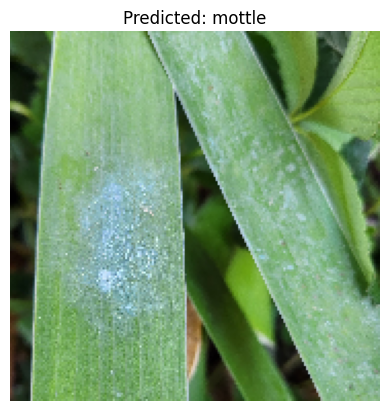

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ✅ Pick a random image path from the dataset
import os
import glob

# Recursively find all images
all_image_paths = glob.glob('/content/ragi/**/*.*', recursive=True)
random_image_path = random.choice(all_image_paths)
print(f"Selected image: {random_image_path}")

# ✅ Load and preprocess image
img = image.load_img(random_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape becomes (1, height, width, 3)
img_array /= 255.0  # same as our Rescaling layer

# ✅ Make prediction
predictions = model.predict(img_array)
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_idx]

print(f"🔍 Predicted class: {predicted_class_name}")

# ✅ Show image with prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()


cnn + attention now

Found 1514 files belonging to 6 classes.
Using 1212 files for training.
Found 1514 files belonging to 6 classes.
Using 302 files for validation.
Classes: ['downy', 'healthy', 'mottle', 'seedling', 'smut', 'wilt']
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.1955 - loss: 1.8300 - val_accuracy: 0.3477 - val_loss: 1.5604
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.4350 - loss: 1.4706 - val_accuracy: 0.5728 - val_loss: 1.1018
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.5929 - loss: 1.0838 - val_accuracy: 0.6391 - val_loss: 0.9384
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6805 - loss: 0.9159 - val_accuracy: 0.7185 - val_loss: 0.7569
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.7499 - loss: 0.6751 - val_accuracy: 0.7616 - val_loss: 0.6225
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8030 - loss: 0.5508 - val_accuracy: 0.7781 - val_loss: 0.5440
Epoch 7/20
38/38 ━━━━━━━━━━━━━

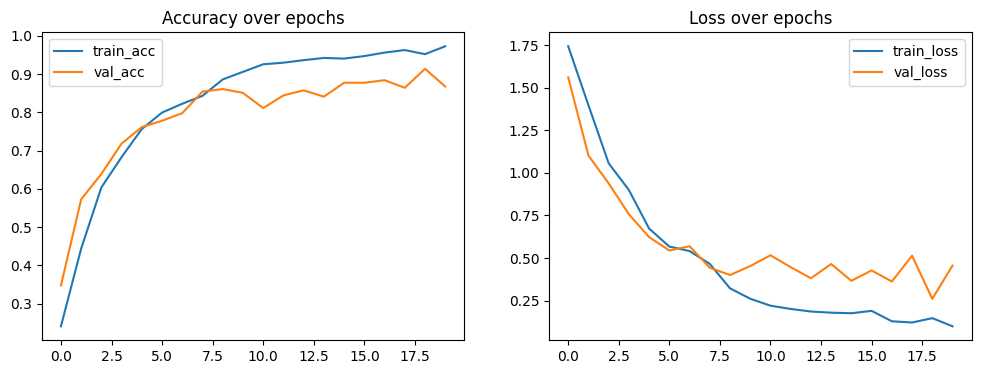

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =====================
# Data loading
# =====================
data_dir = '/content/ragi'
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================
# CNN + simple spatial attention
# =====================
inputs = layers.Input(shape=(img_height, img_width, 3))
x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

# 🧠 Spatial attention
attention = layers.Conv2D(1, kernel_size=1, activation='sigmoid')(x)
x = layers.multiply([x, attention])  # apply attention mask

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

# =====================
# Compile and train
# =====================
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# =====================
# Plot accuracy & loss
# =====================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


Selected image: /content/ragi/wilt/wilt (75).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
🔍 Predicted class: wilt


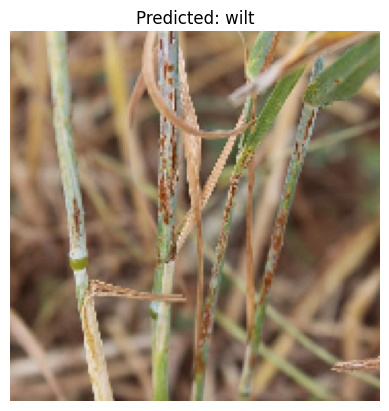

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import glob

# ✅ Pick a random image from your dataset
all_image_paths = glob.glob('/content/ragi/**/*.*', recursive=True)
random_image_path = random.choice(all_image_paths)
print(f"Selected image: {random_image_path}")

# ✅ Load and preprocess
img = image.load_img(random_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape (1, H, W, 3)
img_array /= 255.0  # normalize like training

# ✅ Predict
predictions = model.predict(img_array)
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_idx]

print(f"🔍 Predicted class: {predicted_class_name}")

# ✅ Display image
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()


MobileNetV2

Found 1514 files belonging to 6 classes.
Using 1212 files for training.
Found 1514 files belonging to 6 classes.
Using 302 files for validation.
Classes: ['downy', 'healthy', 'mottle', 'seedling', 'smut', 'wilt']


/tmp/ipython-input-18-1867536743.py:41: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.3357 - loss: 1.8938 - val_accuracy: 0.7550 - val_loss: 0.7027
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7863 - loss: 0.6208 - val_accuracy: 0.8543 - val_loss: 0.4723
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8549 - loss: 0.3904 - val_accuracy: 0.8775 - val_loss: 0.3860
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8689 - loss: 0.3568 - val_accuracy: 0.8907 - val_loss: 0.3436
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9261 - loss: 0.2503 - val_accuracy: 0.9205 - val_loss: 0.3093
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9220 - loss: 0.2375 - val_accuracy: 0.9272 - val_loss: 0.2856
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9384 - loss: 0.1841 - val_accuracy: 0.9371 - val_loss: 0.2578
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9586 

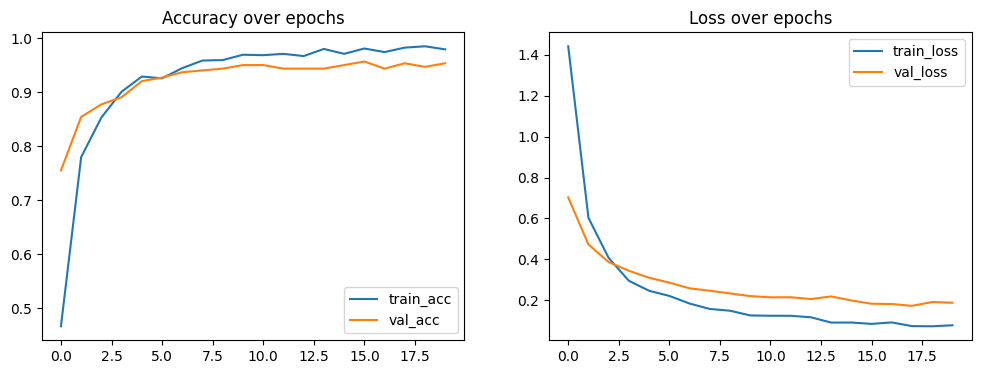

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ================
# Load dataset
# ================
data_dir = '/content/ragi'
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ================
# MobileNetV2 model
# ================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base

# Build classification head
inputs = layers.Input(shape=(img_height, img_width, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ================
# Train for 20 epochs
# ================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# ================
# Plot training history
# ================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


Selected image: /content/ragi/healthy/healthy (91).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
🔍 Predicted class: healthy


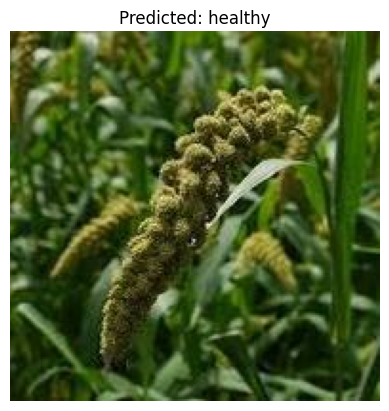

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import glob

# ✅ Pick random image from dataset
all_image_paths = glob.glob('/content/ragi/**/*.*', recursive=True)
random_image_path = random.choice(all_image_paths)
print(f"Selected image: {random_image_path}")

# ✅ Load and preprocess for MobileNetV2
img = image.load_img(random_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape (1, H, W, 3)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# ✅ Predict
predictions = model.predict(img_array)
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_idx]

print(f"🔍 Predicted class: {predicted_class_name}")

# ✅ Show image with prediction
plt.imshow(image.load_img(random_image_path))
plt.title(f"Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()


# work on bajra/pearl millet

Found 339 files belonging to 3 classes.
Using 272 files for training.
Found 339 files belonging to 3 classes.
Using 67 files for validation.
Classes: ['Downy', 'Healthy', 'Rust']
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4045 - loss: 1.2806 - val_accuracy: 0.5821 - val_loss: 0.8513
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6212 - loss: 0.7848 - val_accuracy: 0.8060 - val_loss: 0.6008
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6750 - loss: 0.7182 - val_accuracy: 0.7463 - val_loss: 0.5393
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7895 - loss: 0.5299 - val_accuracy: 0.8806 - val_loss: 0.3868
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8599 - loss: 0.3614 - val_accuracy: 0.8806 - val_loss: 0.3853
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8287 - loss: 0.4065 - val_accuracy: 0.8806 - val_loss: 0.3269
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8958 - loss: 0.3083 - val_accuracy: 0.8955 - val_loss: 0.2591
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9254 - loss: 0.2333 - val_accuracy: 0.9104 - val_loss: 0.2508
Epoch 9/20
9/9 ━━━━

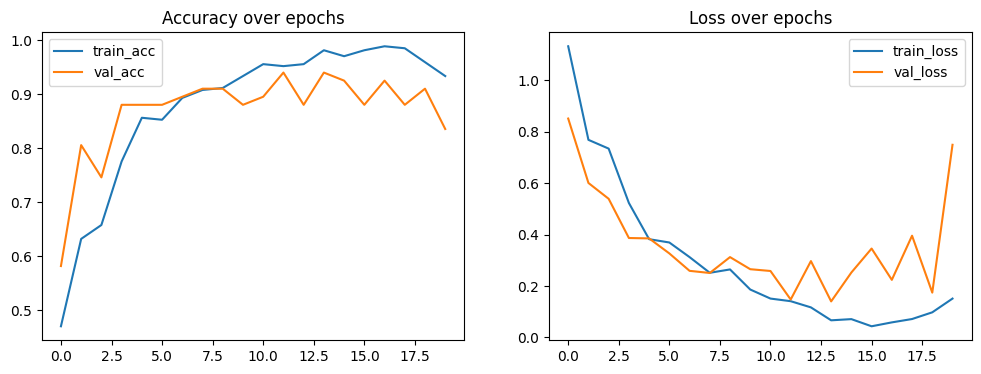

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ================
# Load bajra dataset
# ================
data_dir = '/content/bajra_sorted'
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ================
# Build simple CNN
# ================
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ================
# Train for 20 epochs
# ================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# ================
# Plot training curves
# ================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


Selected image: /content/bajra_sorted/Rust/20210917_095328_jpg.rf.d2d04df25447bb14562972b8282e44d3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
🔍 Predicted class: Healthy


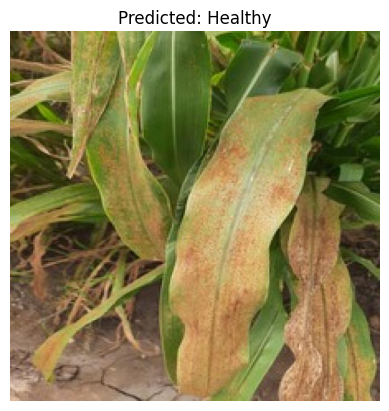

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import glob

# ✅ Pick random image from bajra dataset
all_image_paths = glob.glob('/content/bajra_sorted/**/*.*', recursive=True)
random_image_path = random.choice(all_image_paths)
print(f"Selected image: {random_image_path}")

# ✅ Load and preprocess
img = image.load_img(random_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# ✅ Predict
predictions = model.predict(img_array)
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_idx]

print(f"🔍 Predicted class: {predicted_class_name}")

# ✅ Display
plt.imshow(image.load_img(random_image_path))
plt.title(f"Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()


cnn+ attention

Found 339 files belonging to 3 classes.
Using 272 files for training.
Found 339 files belonging to 3 classes.
Using 67 files for validation.
Classes: ['Downy', 'Healthy', 'Rust']
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.3978 - loss: 1.8380 - val_accuracy: 0.7463 - val_loss: 0.8765
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6470 - loss: 0.8326 - val_accuracy: 0.6269 - val_loss: 0.9249
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7384 - loss: 0.5885 - val_accuracy: 0.7164 - val_loss: 0.5853
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7390 - loss: 0.5612 - val_accuracy: 0.9104 - val_loss: 0.2970
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8519 - loss: 0.3610 - val_accuracy: 0.6567 - val_loss: 0.8058
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7963 - loss: 0.5753 - val_accuracy: 0.7164 - val_loss: 0.6970
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8

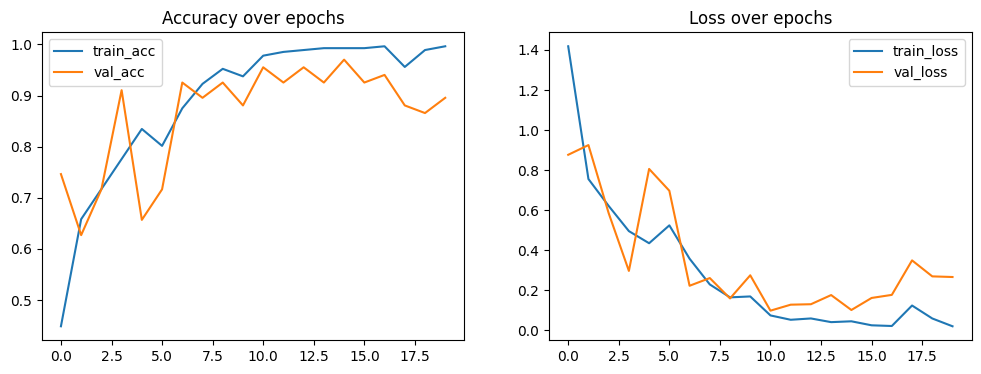

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ====================
# Load bajra dataset
# ====================
data_dir = '/content/bajra_sorted'
batch_size = 16
img_height = 128
img_width = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ====================
# Middle-ground CNN + attention
# ====================
inputs = layers.Input(shape=(img_height, img_width, 3))
x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

# 🧠 Simple attention
attention = layers.Conv2D(1, kernel_size=1, activation='sigmoid')(x)
x = layers.multiply([x, attention])

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

# ====================
# Compile & train
# ====================
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# ====================
# Plot accuracy & loss
# ====================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


Selected image: /content/bajra_sorted/Healthy/20210827_111314_jpg.rf.45cdfb922ec2f70032194351114523d9.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
🔍 Predicted class: Healthy


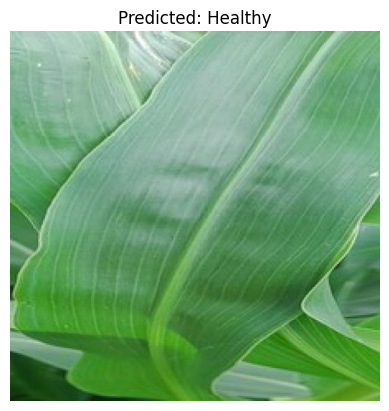

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import glob

# ✅ Pick random bajra image
all_image_paths = glob.glob('/content/bajra_sorted/**/*.*', recursive=True)
random_image_path = random.choice(all_image_paths)
print(f"Selected image: {random_image_path}")

# ✅ Preprocess
img = image.load_img(random_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# ✅ Predict
predictions = model.predict(img_array)
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_idx]

print(f"🔍 Predicted class: {predicted_class_name}")
plt.imshow(image.load_img(random_image_path))
plt.title(f"Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()


MobileNetV2

Found 339 files belonging to 3 classes.
Using 272 files for training.
Found 339 files belonging to 3 classes.
Using 67 files for validation.
Classes: ['Downy', 'Healthy', 'Rust']


/tmp/ipython-input-6-806315419.py:41: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.3625 - loss: 1.5379 - val_accuracy: 0.6866 - val_loss: 0.7672
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6300 - loss: 0.8370 - val_accuracy: 0.8507 - val_loss: 0.4798
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 877ms/step - accuracy: 0.7331 - loss: 0.6044 - val_accuracy: 0.9254 - val_loss: 0.3489
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8645 - loss: 0.3689 - val_accuracy: 0.9254 - val_loss: 0.2835
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 997ms/step - accuracy: 0.8527 - loss: 0.3282 - val_accuracy: 0.9552 - val_loss: 0.2315
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 877ms/step - accuracy: 0.9069 - loss: 0.2439 - val_accuracy: 0.9552 - val_loss: 0.2016
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 962ms/step - accuracy: 0.9465 - loss: 0.1937 - val_accuracy: 0.9851 - val_loss: 0.1846
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9768 - loss: 0.1513 - val_accuracy: 0.9851 - val_loss: 0.1672
E

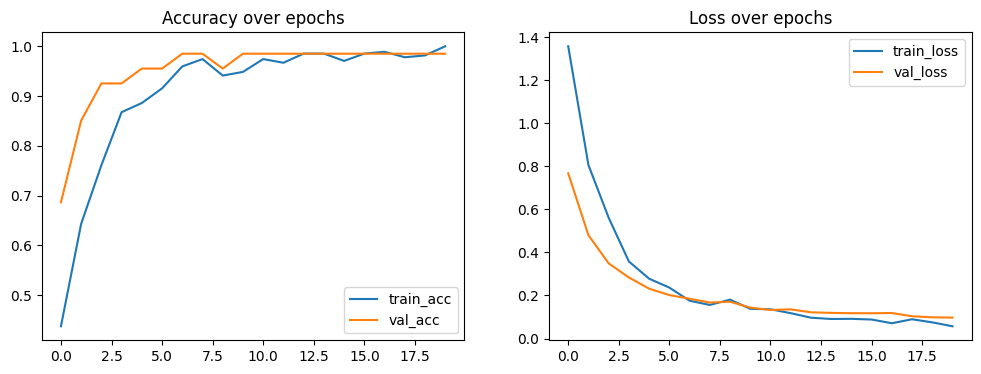

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =====================
# Load bajra dataset
# =====================
data_dir = '/content/bajra_sorted'
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================
# MobileNetV2 model
# =====================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze feature extractor

inputs = layers.Input(shape=(img_height, img_width, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# =====================
# Train for 20 epochs
# =====================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# =====================
# Plot results
# =====================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


Selected image: /content/bajra_sorted/Rust/20201029_093240_jpg.rf.a1265b8f26a41042495ab510b37e3ea0.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
🔍 Predicted class: Rust


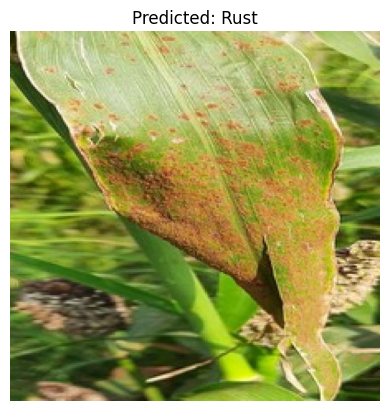

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import glob

all_image_paths = glob.glob('/content/bajra_sorted/**/*.*', recursive=True)
random_image_path = random.choice(all_image_paths)
print(f"Selected image: {random_image_path}")

img = image.load_img(random_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

predictions = model.predict(img_array)
predicted_class_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_idx]

print(f"🔍 Predicted class: {predicted_class_name}")
plt.imshow(image.load_img(random_image_path))
plt.title(f"Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()


# accuracies

Found 339 files belonging to 3 classes.
Using 272 files for training.
Found 339 files belonging to 3 classes.
Using 67 files for validation.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3496 - loss: 2.5687 - val_accuracy: 0.5075 - val_loss: 0.8739
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5531 - loss: 0.8928 - val_accuracy: 0.9104 - val_loss: 0.3430
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8154 - loss: 0.4743 - val_accuracy: 0.8507 - val_loss: 0.3697
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8645 - loss: 0.3850 - val_accuracy: 0.8358 - val_loss: 0.4342
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8498 - loss: 0.4097 - val_accuracy: 0.8209 - val_loss: 0.5413
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9276 - loss: 0.1921 - val_accuracy: 0.8657 - val_loss: 0.2316
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9206 - loss: 0.2367 - val_accuracy: 0.9403 - val_loss: 0.1715
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9720 - loss: 0.1301 - val_accuracy: 0.9403 - val_loss:

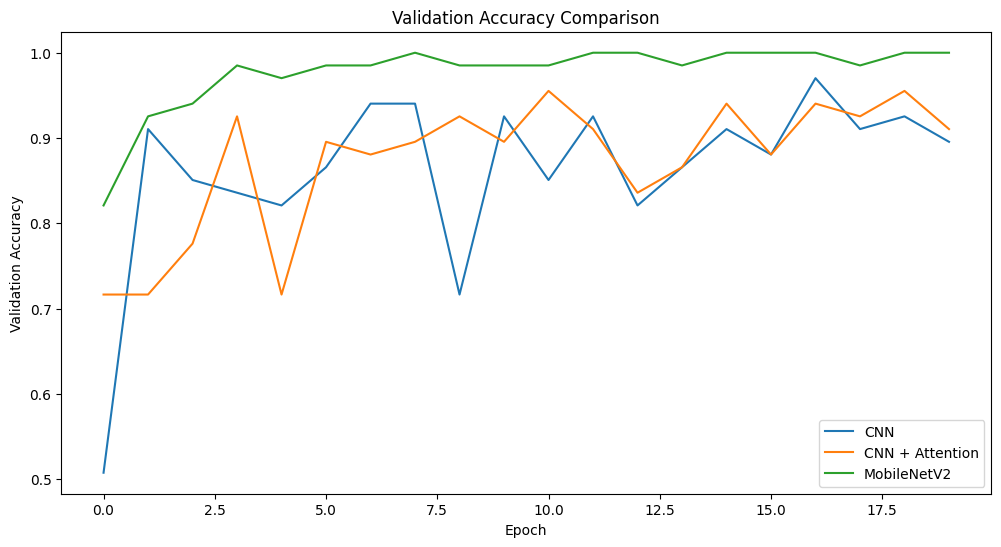

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =====================
# Load bajra dataset
# =====================
data_dir = '/content/bajra_sorted'
batch_size = 16
img_height = 128
img_width = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================
# 1️⃣ Simple CNN
# =====================
model_cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn = model_cnn.fit(train_ds, validation_data=val_ds, epochs=20)

# =====================
# 2️⃣ CNN + Attention
# =====================
inputs = layers.Input(shape=(img_height, img_width, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)
attention = layers.Conv2D(1, 1, activation='sigmoid')(x)
x = layers.multiply([x, attention])
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)
model_cnn_attention = models.Model(inputs, outputs)

model_cnn_attention.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn_attention = model_cnn_attention.fit(train_ds, validation_data=val_ds, epochs=20)

# =====================
# 3️⃣ MobileNetV2
# =====================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(img_height, img_width, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model_mobilenet = models.Model(inputs, outputs)
model_mobilenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_mobilenet = model_mobilenet.fit(train_ds, validation_data=val_ds, epochs=20)

# =====================
# 📊 Compare accuracies
# =====================
plt.figure(figsize=(12,6))
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.plot(history_cnn_attention.history['val_accuracy'], label='CNN + Attention')
plt.plot(history_mobilenet.history['val_accuracy'], label='MobileNetV2')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()


Found 1514 files belonging to 6 classes.
Using 1212 files for training.
Found 1514 files belonging to 6 classes.
Using 302 files for validation.
Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.1792 - loss: 2.3558 - val_accuracy: 0.3377 - val_loss: 1.5687
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.4691 - loss: 1.3720 - val_accuracy: 0.5960 - val_loss: 1.1407
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6366 - loss: 0.9710 - val_accuracy: 0.6887 - val_loss: 0.8424
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7909 - loss: 0.6191 - val_accuracy: 0.7748 - val_loss: 0.6034
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8858 - loss: 0.3470 - val_accuracy: 0.7980 - val_loss: 0.5375
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9075 - loss: 0.2776 - val_accuracy: 0.8212 - val_loss: 0.5208
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9506 - loss: 0.1754 - val_accura

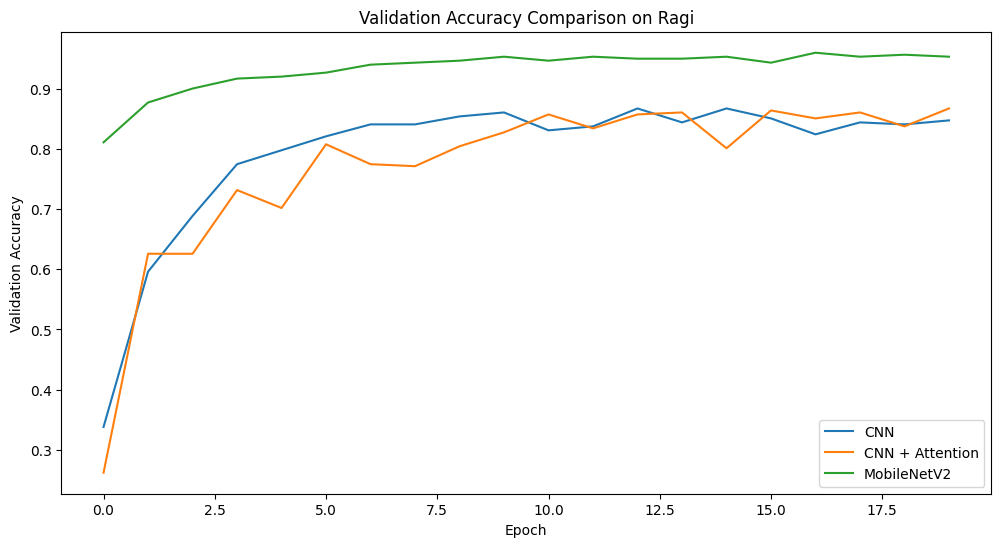

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =====================
# Load ragi dataset
# =====================
data_dir = '/content/ragi'
batch_size = 16
img_height = 128
img_width = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================
# 1️⃣ Simple CNN
# =====================
model_cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn = model_cnn.fit(train_ds, validation_data=val_ds, epochs=20)

# =====================
# 2️⃣ CNN + Attention
# =====================
inputs = layers.Input(shape=(img_height, img_width, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)
attention = layers.Conv2D(1, 1, activation='sigmoid')(x)
x = layers.multiply([x, attention])
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)
model_cnn_attention = models.Model(inputs, outputs)

model_cnn_attention.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn_attention = model_cnn_attention.fit(train_ds, validation_data=val_ds, epochs=20)

# =====================
# 3️⃣ MobileNetV2
# =====================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(img_height, img_width, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model_mobilenet = models.Model(inputs, outputs)
model_mobilenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_mobilenet = model_mobilenet.fit(train_ds, validation_data=val_ds, epochs=20)

# =====================
# 📊 Compare accuracies
# =====================
plt.figure(figsize=(12,6))
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.plot(history_cnn_attention.history['val_accuracy'], label='CNN + Attention')
plt.plot(history_mobilenet.history['val_accuracy'], label='MobileNetV2')
plt.title('Validation Accuracy Comparison on Ragi')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
